In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews


In [4]:
import os
print(os.listdir(path))

['IMDB Dataset.csv']


In [5]:
import pandas as pd
df = pd.read_csv(os.path.join(path, 'IMDB Dataset.csv'))
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df.shape

(50000, 2)

In [7]:
print(df['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x = df['review']
y = df['sentiment']
x_train, x_temp, y_train, y_temp = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size = 0.5,
    random_state = 42,
    stratify = y_temp
)

In [10]:
print(len(x_train))
print(len(x_val))
print(len(x_test))

40000
5000
5000


In [11]:
y_train = y_train.map({'negative': 0, 'positive': 0})
y_test = y_test.map({'negative': 0, 'positive': 0})
y_val = y_val.map({'negative': 0, 'positive': 0})

In [12]:
x_train.head()

47808    I caught this little gem totally by accident b...
20154    I can't believe that I let myself into this mo...
43069    *spoiler alert!* it just gets to me the nerve ...
19413    If there's one thing I've learnt from watching...
13673    I remember when this was in theaters, reviews ...
Name: review, dtype: object

In [13]:
def tokenizer(review):
    review = review.replace('<br />', '')
    return review.lower().split()
x_train = x_train.apply(tokenizer)

In [14]:
from collections import Counter
counter = Counter()
for review in x_train:
    counter.update(review)
print(counter.most_common(20))    

[('the', 513070), ('a', 253774), ('and', 251300), ('of', 229569), ('to', 212132), ('is', 163751), ('in', 144235), ('i', 114593), ('this', 111563), ('that', 104298), ('it', 104128), ('was', 74952), ('as', 70844), ('for', 68034), ('with', 67820), ('but', 62244), ('on', 50352), ('movie', 49206), ('are', 45710), ('his', 45530)]


In [15]:
unique = [word for word, count in counter.most_common(20000)]
word_to_int = {
    '<PAD>': 0,
    '<UNK>': 1
}
for index, word in enumerate(unique, start = 2):
    word_to_int[word] = index

In [16]:
print(len(word_to_int))
print(list(word_to_int.items())[:10])

20002
[('<PAD>', 0), ('<UNK>', 1), ('the', 2), ('a', 3), ('and', 4), ('of', 5), ('to', 6), ('is', 7), ('in', 8), ('i', 9)]


In [17]:
int_to_word = {}
int_to_word = {
    0 : '<PAD>',
    1 : '<UNK>'
}
for index, word in enumerate(unique, start = 2):
    int_to_word[index] = word

In [18]:
print(len(int_to_word))
print(list(int_to_word.items())[:10])

20002
[(0, '<PAD>'), (1, '<UNK>'), (2, 'the'), (3, 'a'), (4, 'and'), (5, 'of'), (6, 'to'), (7, 'is'), (8, 'in'), (9, 'i')]


In [19]:
def tokenized(review):
    l = []
    for i in review:
        l.append(word_to_int.get(i, 1))
    return l    
l = tokenized(x_train.iloc[0]) 
print(l)

[9, 998, 10, 104, 2189, 389, 30, 2371, 151, 8, 8913, 39, 1, 9, 13, 28, 3, 10891, 2130, 6, 65, 101, 171, 759, 1001, 553, 2, 2130, 13, 3627, 332, 4, 1639, 59, 1, 32, 1145, 3, 701, 5, 1001, 381, 10372, 3974, 71, 187, 8, 2, 1, 76, 66, 580, 1416, 17, 10, 319, 18, 478, 699, 9922, 2, 352, 13, 8, 1, 2, 1004, 512, 319, 48, 32, 1145, 1, 1, 245, 555, 1, 1, 341, 5, 1574, 18, 44, 2928, 56, 259, 28, 2, 3696, 345, 3, 4140, 2419, 4, 1, 11, 95, 12, 53, 1, 23, 3377, 65, 1, 253, 30, 47, 259, 36, 3, 1, 12, 13, 491, 759, 4, 1, 9, 360, 562, 6611, 76, 5, 2, 493, 13, 10373, 46, 75, 5, 34, 2, 8689, 80, 43, 23, 112, 5547, 12215, 169, 105, 42, 53, 1, 4386, 11046, 293, 28, 45, 5, 2, 2893, 10, 60, 535, 16, 31, 1, 3, 3580, 9923]


In [20]:
x_train = x_train.apply(tokenized)

In [21]:
lengths = x_train.apply(len)
print("Minimum:", lengths.min())
print("Maximum:", lengths.max())
print("Average:", lengths.mean())

print("90th percentile:", lengths.quantile(0.90))
print("95th percentile:", lengths.quantile(0.95))
print("99th percentile:", lengths.quantile(0.99))

Minimum: 4
Maximum: 2450
Average: 227.331975
90th percentile: 444.0
95th percentile: 580.0
99th percentile: 890.0


In [22]:
train_lengths = x_train.apply(len)
val_lengths = x_val.apply(len)
test_lengths = x_test.apply(len)

train_lengths = train_lengths.clip(upper=500)
val_lengths = val_lengths.clip(upper=500)
test_lengths = test_lengths.clip(upper=500)

In [23]:
print(train_lengths.head(10))
print(train_lengths.min())
print(train_lengths.max())

47808    161
20154    168
43069     69
19413    306
13673    177
40368    203
15432    210
10208    500
42345    404
42141    263
Name: review, dtype: int64
4
500


In [24]:
def cut(review):
    if len(review) > 500:
        review = review[:500]
    elif len(review) < 500:
        l = 500 - len(review)
        for _ in range(l):
            review.append(0)
    return review  
demo = cut(x_train[0])
print(demo)

[29, 5, 2, 79, 2168, 40, 1199, 11, 92, 146, 38, 841, 5606, 469, 411, 27, 12149, 32, 20, 2207, 14, 10, 7, 542, 47, 689, 16, 10851, 86, 166, 11, 3251, 85, 41, 5606, 13, 83, 6745, 4, 19518, 154, 5, 2176, 63, 283, 8, 241, 33, 2, 778, 3084, 1839, 484, 10, 7, 22, 3, 128, 15, 2, 9285, 7106, 39, 1, 10, 128, 2478, 59, 7943, 16, 7068, 6, 4832, 440, 39, 3232, 83, 7, 1, 8, 2, 417, 309, 5, 2, 1, 7, 426, 5606, 14, 11, 7, 2, 15154, 318, 6, 2, 1, 8148, 2721, 1238, 1, 12, 2612, 1360, 18, 1, 3099, 31, 5132, 3182, 5, 2, 1487, 102, 34, 2, 9622, 25, 3741, 1, 4, 465, 1, 37, 1, 7, 22, 308, 18, 2, 18798, 13382, 698, 7, 413, 6, 1, 1, 1, 1, 1, 1, 2597, 4, 1, 1, 435, 1, 8715, 17793, 4, 9479, 1, 20, 100, 223, 1, 52, 136, 2, 250, 1458, 5, 2, 128, 7, 614, 6, 2, 229, 11, 12, 256, 102, 79, 276, 499, 1, 811, 169, 1608, 4399, 15, 2850, 7855, 811, 7667, 811, 1, 141, 1413, 2347, 2, 86, 469, 9, 122, 193, 3251, 85, 14, 37, 1735, 12, 13, 12268, 9, 360, 136, 9, 13, 1516, 15, 194, 17, 14, 9, 258, 2078, 9, 1737, 3, 1661, 15, 1

In [25]:
x_train = x_train.apply(cut)

In [26]:
x_train.apply(len).value_counts()

review
500    40000
Name: count, dtype: int64

In [27]:
x_val = x_val.apply(tokenizer)
x_val = x_val.apply(tokenized)
x_val = x_val.apply(cut)

In [28]:
x_val.apply(len).value_counts()

review
500    5000
Name: count, dtype: int64

In [29]:
x_test = x_test.apply(tokenizer)
x_test = x_test.apply(tokenized)
x_test = x_test.apply(cut)
x_test.apply(len).value_counts()

review
500    5000
Name: count, dtype: int64

In [30]:
print(len(x_train.iloc[0]))
print(len(x_val.iloc[0]))
print(len(x_test.iloc[0]))

500
500
500


In [32]:
import torch

In [33]:
print(torch.cuda.is_available())

True


In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [38]:
print("Train:", len(x_train))
print("Validation:", len(x_val))
print("Test:", len(x_test))

print("Train + Validation + Test:",
      len(x_train) + len(x_val) + len(x_test))

Train: 40000
Validation: 5000
Test: 5000
Train + Validation + Test: 50000


In [39]:
train_set = set(tuple(x) for x in x_train)
val_set = set(tuple(x) for x in x_val)
test_set = set(tuple(x) for x in x_test)

print("Train ∩ Validation:", len(train_set & val_set))
print("Train ∩ Test:", len(train_set & test_set))
print("Validation ∩ Test:", len(val_set & test_set))

Train ∩ Validation: 68
Train ∩ Test: 67
Validation ∩ Test: 3


In [40]:
print(y_train.value_counts())
print(y_val.value_counts())
print(y_test.value_counts())

sentiment
0    40000
Name: count, dtype: int64
sentiment
0    5000
Name: count, dtype: int64
sentiment
0    5000
Name: count, dtype: int64


In [41]:
print(df['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [42]:
y = df['sentiment'].map({'negative': 0, 'positive': 1})

print(y.value_counts())

sentiment
1    25000
0    25000
Name: count, dtype: int64


In [44]:
from sklearn.model_selection import train_test_split

_, y_temp = train_test_split(
    df['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment']
)

y_train, y_temp = train_test_split(
    df['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment']
)

y_val, y_test = train_test_split(
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

y_train = y_train.map({'negative': 0, 'positive': 1})
y_val = y_val.map({'negative': 0, 'positive': 1})
y_test = y_test.map({'negative': 0, 'positive': 1})

print(y_train.value_counts())
print(y_val.value_counts())
print(y_test.value_counts())

sentiment
1    20000
0    20000
Name: count, dtype: int64
sentiment
0    2500
1    2500
Name: count, dtype: int64
sentiment
0    2500
1    2500
Name: count, dtype: int64


In [45]:
print(y_train.head())
print(y_val.head())
print(y_test.head())

47808    1
20154    0
43069    0
19413    0
13673    0
Name: sentiment, dtype: int64
42623    0
23391    0
49491    0
48512    1
23744    0
Name: sentiment, dtype: int64
46799    0
45891    1
48397    1
30342    0
32483    0
Name: sentiment, dtype: int64


In [46]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class IMDBDataset(Dataset):
    def __init__(self, x, y, lengths):
        self.x = x
        self.y = y
        self.lengths = lengths

    def __len__(self):
        return len(self.x)

    def __getitem__(self, index):
        review = torch.tensor(self.x.iloc[index], dtype=torch.long)
        label = torch.tensor(self.y.iloc[index], dtype=torch.float)
        length = torch.tensor(self.lengths.iloc[index], dtype=torch.long)

        return review, label, length


train_dataset = IMDBDataset(x_train, y_train, train_lengths)
val_dataset = IMDBDataset(x_val, y_val, val_lengths)
test_dataset = IMDBDataset(x_test, y_test, test_lengths)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [47]:
reviews, labels, lengths = next(iter(train_loader))

print(reviews.shape)
print(labels.shape)
print(lengths.shape)
print(lengths[:10])

torch.Size([64, 500])
torch.Size([64])
torch.Size([64])
tensor([384, 185,  63, 370, 174, 188, 345, 190, 132, 294])


In [48]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence


class SentimentLSTM(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, lengths):

        x = self.embedding(x)

        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        output, (hidden, cell) = self.lstm(packed)

        last_hidden = hidden[-1]

        x = self.fc(last_hidden)

        return x

In [49]:
model = SentimentLSTM(
    vocab_size=20002,
    embedding_dim=128,
    hidden_size=128
)

model = model.to(device)

In [50]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [51]:
reviews, labels, lengths = next(iter(train_loader))

reviews = reviews.to(device)
labels = labels.to(device)
lengths = lengths.to(device)

output = model(reviews, lengths)

print(output.shape)

torch.Size([64, 1])


In [52]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(10):

    # ---------- TRAINING ----------
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for reviews, labels, lengths in train_loader:

        reviews = reviews.to(device)
        labels = labels.to(device)
        lengths = lengths.to(device)

        optimizer.zero_grad()

        output = model(reviews, lengths)

        loss = criterion(output.squeeze(1), labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        predictions = (torch.sigmoid(output.squeeze(1)) >= 0.5).float()

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_accuracy = correct / total

    # ---------- VALIDATION ----------
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for reviews, labels, lengths in val_loader:

            reviews = reviews.to(device)
            labels = labels.to(device)
            lengths = lengths.to(device)

            output = model(reviews, lengths)

            loss = criterion(output.squeeze(1), labels)

            total_loss += loss.item()

            predictions = (torch.sigmoid(output.squeeze(1)) >= 0.5).float()

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_accuracy = correct / total

    # ---------- SAVE RESULTS ----------
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch + 1}/10 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy * 100:.2f}%"
    )

Epoch 1/10 | Train Loss: 0.6114 | Train Acc: 66.40% | Val Loss: 0.6329 | Val Acc: 67.40%
Epoch 2/10 | Train Loss: 0.5553 | Train Acc: 71.75% | Val Loss: 0.6631 | Val Acc: 68.78%
Epoch 3/10 | Train Loss: 0.3735 | Train Acc: 83.76% | Val Loss: 0.7203 | Val Acc: 82.92%
Epoch 4/10 | Train Loss: 0.2779 | Train Acc: 88.87% | Val Loss: 0.6478 | Val Acc: 85.24%
Epoch 5/10 | Train Loss: 0.2100 | Train Acc: 92.05% | Val Loss: 0.7874 | Val Acc: 84.42%
Epoch 6/10 | Train Loss: 0.1602 | Train Acc: 94.26% | Val Loss: 1.0413 | Val Acc: 83.18%
Epoch 7/10 | Train Loss: 0.1199 | Train Acc: 95.99% | Val Loss: 1.0181 | Val Acc: 85.14%
Epoch 8/10 | Train Loss: 0.0846 | Train Acc: 97.39% | Val Loss: 0.9810 | Val Acc: 87.96%
Epoch 9/10 | Train Loss: 0.0700 | Train Acc: 97.84% | Val Loss: 1.2316 | Val Acc: 85.10%
Epoch 10/10 | Train Loss: 0.0441 | Train Acc: 98.79% | Val Loss: 1.1902 | Val Acc: 87.60%


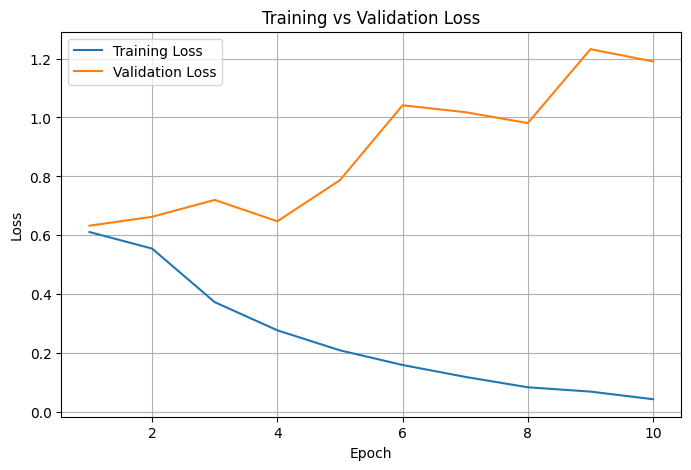

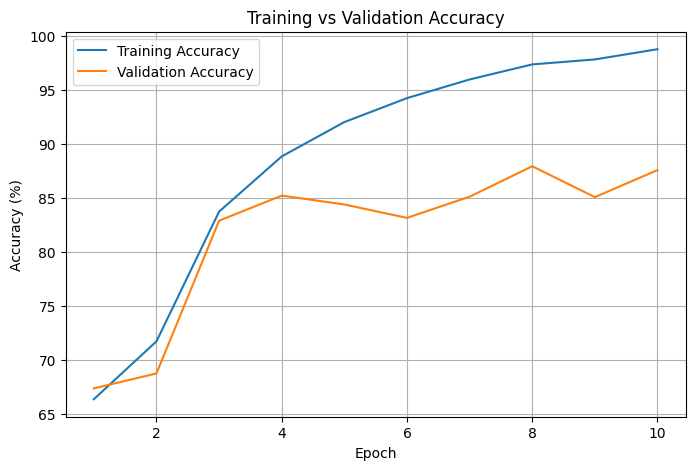

In [53]:
import matplotlib.pyplot as plt

epochs = range(1, 11)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Training Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, [x * 100 for x in train_accuracies], label="Training Accuracy")
plt.plot(epochs, [x * 100 for x in val_accuracies], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

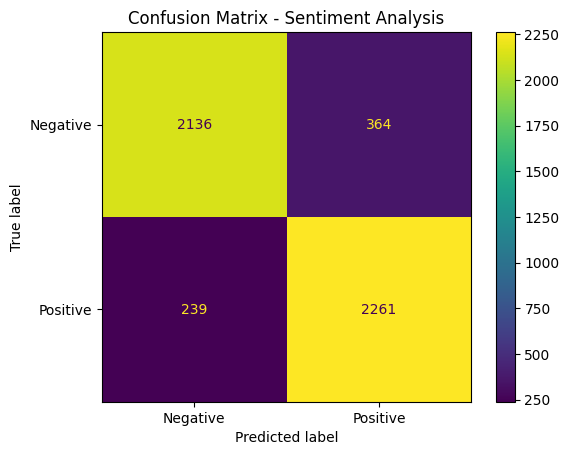

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for reviews, labels, lengths in test_loader:
        reviews = reviews.to(device)
        labels = labels.to(device)
        lengths = lengths.to(device)

        output = model(reviews, lengths)

        predictions = (torch.sigmoid(output.squeeze(1)) >= 0.5).long()

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix - Sentiment Analysis")
plt.show()

In [55]:
def predict_sentiment(review):
    tokens = tokenizer(review)
    
    length = min(len(tokens), 500)
    
    sequence = tokenized(tokens)
    sequence = cut(sequence)
    
    review_tensor = torch.tensor(sequence, dtype=torch.long).unsqueeze(0).to(device)
    length_tensor = torch.tensor([length], dtype=torch.long).to(device)

    model.eval()

    with torch.no_grad():
        output = model(review_tensor, length_tensor)
        probability = torch.sigmoid(output).item()

    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("Review:", review)
    print("Prediction:", sentiment)
    print("Positive probability:", f"{probability * 100:.2f}%")

In [56]:
predict_sentiment(
    "This movie was absolutely amazing. The acting was excellent and I loved every minute of it."
)

predict_sentiment(
    "The movie was boring and predictable. I did not enjoy it at all."
)

predict_sentiment(
    "The story was interesting and the performances were really good."
)

Review: This movie was absolutely amazing. The acting was excellent and I loved every minute of it.
Prediction: Positive
Positive probability: 99.92%
Review: The movie was boring and predictable. I did not enjoy it at all.
Prediction: Negative
Positive probability: 0.02%
Review: The story was interesting and the performances were really good.
Prediction: Positive
Positive probability: 95.43%


In [58]:
predict_sentiment(
    "The movie looked beautiful and the actors gave convincing performances, "
    "but somehow I spent most of the runtime checking how much longer was left."
)

predict_sentiment(
    "I wouldn't say I loved it, but I also can't deny that I kept thinking "
    "about the story long after the credits."
)

predict_sentiment(
    "The first half was painfully slow, the dialogue was awkward, and yet "
    "the final act somehow made the entire experience feel worthwhile."
)

predict_sentiment(
    "There is absolutely nothing wrong with this movie. The acting is fine, "
    "the story is fine, and everything works exactly as expected."
)

predict_sentiment(
    "It wasn't particularly funny, wasn't particularly emotional, and wasn't "
    "particularly memorable. Strangely, I still enjoyed watching it."
)

Review: The movie looked beautiful and the actors gave convincing performances, but somehow I spent most of the runtime checking how much longer was left.
Prediction: Negative
Positive probability: 6.33%
Review: I wouldn't say I loved it, but I also can't deny that I kept thinking about the story long after the credits.
Prediction: Positive
Positive probability: 80.29%
Review: The first half was painfully slow, the dialogue was awkward, and yet the final act somehow made the entire experience feel worthwhile.
Prediction: Negative
Positive probability: 0.06%
Review: There is absolutely nothing wrong with this movie. The acting is fine, the story is fine, and everything works exactly as expected.
Prediction: Positive
Positive probability: 90.36%
Review: It wasn't particularly funny, wasn't particularly emotional, and wasn't particularly memorable. Strangely, I still enjoyed watching it.
Prediction: Positive
Positive probability: 86.74%


In [59]:
import os
import pickle
import torch

# Create folder
os.makedirs("sentiment_analysis_models/LSTM", exist_ok=True)

# 1. Save trained model weights
torch.save(
    model.state_dict(),
    "sentiment_analysis_models/LSTM/model.pth"
)

# 2. Save vocabulary
with open(
    "sentiment_analysis_models/LSTM/word_to_int.pkl",
    "wb"
) as f:
    pickle.dump(word_to_int, f)

# 3. Save model configuration
config = {
    "vocab_size": 20002,
    "embedding_dim": 128,
    "hidden_size": 128,
    "max_len": 500
}

with open(
    "sentiment_analysis_models/LSTM/config.pkl",
    "wb"
) as f:
    pickle.dump(config, f)

print("LSTM model saved successfully!")

LSTM model saved successfully!


In [60]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence


class SentimentBiLSTM(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_size, dropout=0.5):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_size * 2,
            1
        )

    def forward(self, x, lengths):

        x = self.embedding(x)

        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        output, (hidden, cell) = self.lstm(packed)

        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]

        last_hidden = torch.cat(
            (forward_hidden, backward_hidden),
            dim=1
        )

        x = self.dropout(last_hidden)

        x = self.fc(x)

        return x

In [61]:
model = SentimentBiLSTM(
    vocab_size=20002,
    embedding_dim=128,
    hidden_size=128,
    dropout=0.5
)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

SentimentBiLSTM(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


In [62]:
reviews, labels, lengths = next(iter(train_loader))

reviews = reviews.to(device)
labels = labels.to(device)
lengths = lengths.to(device)

output = model(reviews, lengths)

print("Input shape:", reviews.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([64, 500])
Output shape: torch.Size([64, 1])


In [63]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(10):

    # Training
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for reviews, labels, lengths in train_loader:

        reviews = reviews.to(device)
        labels = labels.to(device)
        lengths = lengths.to(device)

        optimizer.zero_grad()

        output = model(reviews, lengths)

        loss = criterion(
            output.squeeze(1),
            labels
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = (
            torch.sigmoid(output.squeeze(1)) >= 0.5
        ).float()

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_accuracy = correct / total

    # Validation
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for reviews, labels, lengths in val_loader:

            reviews = reviews.to(device)
            labels = labels.to(device)
            lengths = lengths.to(device)

            output = model(reviews, lengths)

            loss = criterion(
                output.squeeze(1),
                labels
            )

            total_loss += loss.item()

            predictions = (
                torch.sigmoid(output.squeeze(1)) >= 0.5
            ).float()

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_accuracy = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch + 1}/10 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy * 100:.2f}%"
    )

Epoch 1/10 | Train Loss: 0.6343 | Train Acc: 64.06% | Val Loss: 0.6935 | Val Acc: 52.30%
Epoch 2/10 | Train Loss: 0.4776 | Train Acc: 76.96% | Val Loss: 0.5703 | Val Acc: 71.16%
Epoch 3/10 | Train Loss: 0.3090 | Train Acc: 87.02% | Val Loss: 0.9803 | Val Acc: 74.44%
Epoch 4/10 | Train Loss: 0.2183 | Train Acc: 91.62% | Val Loss: 0.4680 | Val Acc: 82.78%
Epoch 5/10 | Train Loss: 0.1585 | Train Acc: 94.27% | Val Loss: 1.0775 | Val Acc: 74.50%
Epoch 6/10 | Train Loss: 0.1171 | Train Acc: 95.94% | Val Loss: 0.5518 | Val Acc: 83.28%
Epoch 7/10 | Train Loss: 0.0802 | Train Acc: 97.42% | Val Loss: 0.6468 | Val Acc: 82.50%
Epoch 8/10 | Train Loss: 0.0549 | Train Acc: 98.30% | Val Loss: 0.5350 | Val Acc: 86.72%
Epoch 9/10 | Train Loss: 0.0384 | Train Acc: 98.84% | Val Loss: 0.8138 | Val Acc: 85.10%
Epoch 10/10 | Train Loss: 0.0282 | Train Acc: 99.14% | Val Loss: 0.6989 | Val Acc: 86.64%


In [64]:
from sklearn.metrics import accuracy_score

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for reviews, labels, lengths in test_loader:

        reviews = reviews.to(device)
        labels = labels.to(device)
        lengths = lengths.to(device)

        output = model(reviews, lengths)

        predictions = (
            torch.sigmoid(output.squeeze(1)) >= 0.5
        ).long()

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"BiLSTM Test Accuracy: {test_accuracy * 100:.2f}%")

BiLSTM Test Accuracy: 86.46%


In [65]:
def predict_sentiment(review):
    tokens = tokenizer(review)
    
    length = min(len(tokens), 500)
    
    sequence = tokenized(tokens)
    sequence = cut(sequence)
    
    review_tensor = torch.tensor(sequence, dtype=torch.long).unsqueeze(0).to(device)
    length_tensor = torch.tensor([length], dtype=torch.long).to(device)

    model.eval()

    with torch.no_grad():
        output = model(review_tensor, length_tensor)
        probability = torch.sigmoid(output).item()

    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("Review:", review)
    print("Prediction:", sentiment)
    print("Positive probability:", f"{probability * 100:.2f}%")

In [66]:
predict_sentiment(
    "The movie looked beautiful and the actors gave convincing performances, "
    "but somehow I spent most of the runtime checking how much longer was left."
)

predict_sentiment(
    "I wouldn't say I loved it, but I also can't deny that I kept thinking "
    "about the story long after the credits."
)

predict_sentiment(
    "The first half was painfully slow, the dialogue was awkward, and yet "
    "the final act somehow made the entire experience feel worthwhile."
)

predict_sentiment(
    "There is absolutely nothing wrong with this movie. The acting is fine, "
    "the story is fine, and everything works exactly as expected."
)

predict_sentiment(
    "It wasn't particularly funny, wasn't particularly emotional, and wasn't "
    "particularly memorable. Strangely, I still enjoyed watching it."
)

Review: The movie looked beautiful and the actors gave convincing performances, but somehow I spent most of the runtime checking how much longer was left.
Prediction: Negative
Positive probability: 0.00%
Review: I wouldn't say I loved it, but I also can't deny that I kept thinking about the story long after the credits.
Prediction: Positive
Positive probability: 99.84%
Review: The first half was painfully slow, the dialogue was awkward, and yet the final act somehow made the entire experience feel worthwhile.
Prediction: Negative
Positive probability: 43.37%
Review: There is absolutely nothing wrong with this movie. The acting is fine, the story is fine, and everything works exactly as expected.
Prediction: Positive
Positive probability: 70.31%
Review: It wasn't particularly funny, wasn't particularly emotional, and wasn't particularly memorable. Strangely, I still enjoyed watching it.
Prediction: Positive
Positive probability: 99.97%


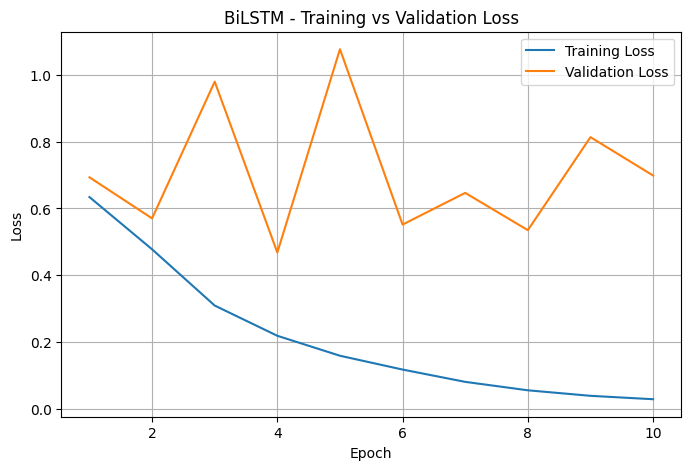

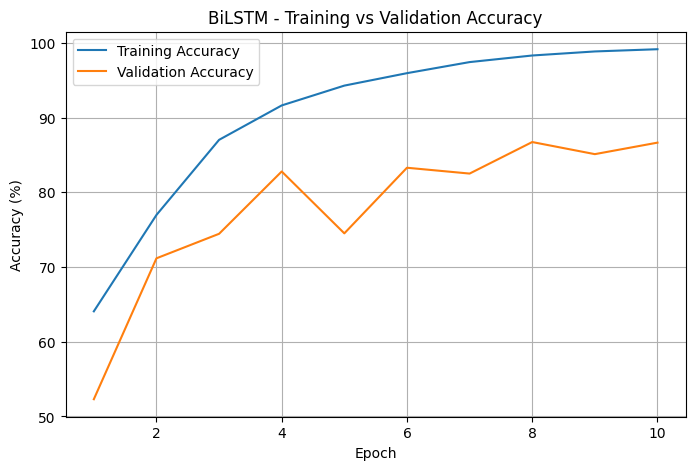

In [67]:
import matplotlib.pyplot as plt

epochs = range(1, 11)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Training Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiLSTM - Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    epochs,
    [x * 100 for x in train_accuracies],
    label="Training Accuracy"
)
plt.plot(
    epochs,
    [x * 100 for x in val_accuracies],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("BiLSTM - Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

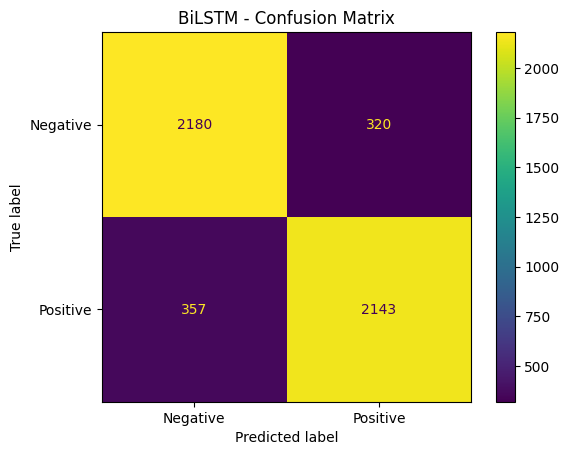

In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for reviews, labels, lengths in test_loader:

        reviews = reviews.to(device)
        labels = labels.to(device)
        lengths = lengths.to(device)

        output = model(reviews, lengths)

        predictions = (
            torch.sigmoid(output.squeeze(1)) >= 0.5
        ).long()

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("BiLSTM - Confusion Matrix")
plt.show()

In [69]:
import os
import pickle
import torch

os.makedirs("sentiment_analysis_models/BiLSTM", exist_ok=True)

# Save model weights
torch.save(
    model.state_dict(),
    "sentiment_analysis_models/BiLSTM/model.pth"
)

# Save vocabulary
with open(
    "sentiment_analysis_models/BiLSTM/word_to_int.pkl",
    "wb"
) as f:
    pickle.dump(word_to_int, f)

# Save model configuration
config = {
    "vocab_size": 20002,
    "embedding_dim": 128,
    "hidden_size": 128,
    "dropout": 0.5,
    "max_len": 500,
    "bidirectional": True
}

with open(
    "sentiment_analysis_models/BiLSTM/config.pkl",
    "wb"
) as f:
    pickle.dump(config, f)

print("BiLSTM model saved successfully!")

BiLSTM model saved successfully!


In [70]:
import shutil

shutil.make_archive(
    "sentiment_analysis_models",
    "zip",
    "sentiment_analysis_models"
)

print("Folder zipped successfully!")

Folder zipped successfully!


In [71]:
import shutil
import os

zip_path = shutil.make_archive(
    "/kaggle/working/sentiment_analysis_models",
    "zip",
    "/kaggle/working/sentiment_analysis_models"
)

print(zip_path)
print(os.path.exists(zip_path))

/kaggle/working/sentiment_analysis_models.zip
True


In [73]:
import shutil

shutil.make_archive(
    "/kaggle/working/sentiment_analysis_models",
    "zip",
    "/kaggle/working/sentiment_analysis_models"
)

print("Created successfully!")

Created successfully!


In [74]:
from IPython.display import FileLink
FileLink(r'sentiment_analysis_models.zip')

/kaggle/working/sentiment_analysis_models.zip